<a href="https://colab.research.google.com/github/PappuBaraf/PappuBaraf/blob/main/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv("/content/Student_Performance.csv")

In [4]:
data

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [5]:
x=data[["study_hours","science_score"]]
y=data["overall_score"]

In [6]:
train_x,test_x,train_y,test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
model= LinearRegression()

In [8]:
model.fit(train_x,train_y)
print(model.intercept_)
print(model.coef_)

18.15502855317454
[4.77506335 0.40062428]


In [9]:
pred_y=model.predict(test_x)
print(pred_y)

[79.76705849 48.534375   65.26864752 ... 31.07249319 90.64133929
 43.49299468]


39.88171305589301
0.890154579431355


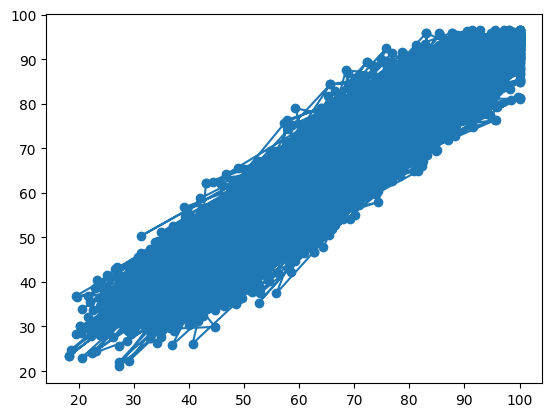

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

print(mean_squared_error(test, model.predict(test_x)))
print(r2_score(test, model.predict(test_x)))

plt.scatter(test, model.predict(test_x))
plt.plot(test, model.predict(test_x))
plt.show()

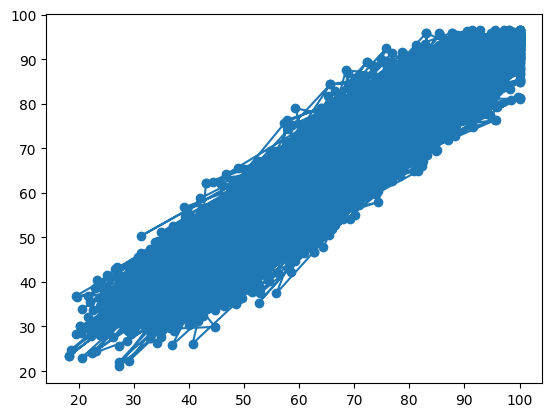

In [11]:
plt.scatter(test,model.predict(test_x))
plt.plot(test,model.predict(test_x))

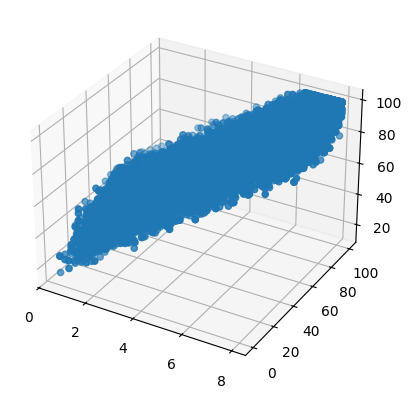

In [12]:
fig=plt.figure()
ax=plt.axes(projection="3d")
ax.scatter3D(train_x["study_hours"],train_x["science_score"],train_y)

In [13]:
ax.plot(train_x["study_hours"], train_x["science_score"], train_y, color="blue")
ax.set_title("3d scatter plot")
plt.show()

In [14]:
r=model.predict([[10,90]])
print(r)

[101.96184725]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
n=len(test_x)
p=2
a=n*np.log(r2_score(test,model.predict(test_x))+2*p)
results_df = pd.DataFrame({"Actual":test,"Predicted":model.predict(test_x)})
print(results_df)

       Actual  Predicted
6868     86.1  79.767058
24016    44.9  48.534375
9668     66.4  65.268648
13640    43.9  46.561588
14018    37.7  42.520619
...       ...        ...
8670     52.2  53.558393
11839    49.2  44.089539
4013     29.0  31.072493
21147    95.3  90.641339
695      53.3  43.492995

[5000 rows x 2 columns]


In [16]:
n=len(test_x)
p=3
a=n*np.log(r2_score(test,model.predict(test_x))+2*p)
results_df = pd.DataFrame({"Actual":test,"Predicted":model.predict(test_x)})
print(results_df)

       Actual  Predicted
6868     86.1  79.767058
24016    44.9  48.534375
9668     66.4  65.268648
13640    43.9  46.561588
14018    37.7  42.520619
...       ...        ...
8670     52.2  53.558393
11839    49.2  44.089539
4013     29.0  31.072493
21147    95.3  90.641339
695      53.3  43.492995

[5000 rows x 2 columns]


In [17]:
x=data[["study_hours","attendance_percentage"]]
y=data["overall_score"]

n=len(test_x)
p=3
a=n*np.log(r2_score(test,model.predict(test_x))+2*p)
results_df = pd.DataFrame({"Actual":test,"Predicted":model.predict(test_x)})
print(results_df)

       Actual  Predicted
6868     86.1  79.767058
24016    44.9  48.534375
9668     66.4  65.268648
13640    43.9  46.561588
14018    37.7  42.520619
...       ...        ...
8670     52.2  53.558393
11839    49.2  44.089539
4013     29.0  31.072493
21147    95.3  90.641339
695      53.3  43.492995

[5000 rows x 2 columns]


In [21]:
import statsmodels.api as sm
data = sm.add_constant(data)
df = pd.DataFrame(data)
df.describe()

,const,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.0,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,1.0,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,0.0,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.0,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,1.0,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,1.0,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,1.0,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,1.0,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000
